# RQ5: Temperature sensitivity across models

Each temperature-run result is paired with its saved base result. The plotted difference is **temperature-run adversarial IoU − saved base adversarial IoU**: zero therefore means no difference.


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()
ABLATION_ROOT = PROJECT_ROOT / "defaults" / "mmm" / "ablation_results"
FIGURE_ROOT = PROJECT_ROOT / "experiments" / "figures"
FIGURE_ROOT.mkdir(exist_ok=True)

MODEL_LABEL = {
    "qwen": "Qwen3-VL",
    "kimi": "Kimi-VL",
    "intern": "InternVL-3.5",
}


def read_json(path):
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except (OSError, ValueError):
        return None


def bbox_list(predictions):
    """Return only the ordered bounding boxes, or None for an unparsable output."""
    if not isinstance(predictions, list):
        return None
    boxes = [item.get("bbox") for item in predictions if isinstance(item, dict)]
    return boxes if len(boxes) == len(predictions) and all(box is not None for box in boxes) else None


def load_temperature_comparison(root=ABLATION_ROOT):
    """Load completed temperature runs and pair each one with its saved base result."""
    rows = []
    for ablation_path in sorted(root.rglob("replicate_*.json")):
        record = read_json(ablation_path)
        if not record or record.get("status") != "complete":
            continue

        base_path = Path(str(record.get("source", {}).get("best_result_json", "")))
        base = read_json(base_path)
        if not base:
            continue

        relative = ablation_path.relative_to(root)
        model = relative.parts[1] if len(relative.parts) > 1 else "unknown"
        base_output = base.get("vlm_output", {})
        temperature_output = record.get("adversarial", {})
        base_iou = float(base.get("objectives", {}).get("iou", np.nan))
        temperature_iou = float(temperature_output.get("iou", np.nan))
        base_text = base_output.get("raw_response")
        temperature_text = temperature_output.get("raw_response")
        base_boxes = bbox_list(base_output.get("parsed_predictions"))
        temperature_boxes = bbox_list(temperature_output.get("parsed_predictions"))

        rows.append({
            "temperature": float(record["temperature"]),
            "model": model,
            "replicate": int(record.get("replicate_index", 0)),
            "base_adversarial_iou": base_iou,
            "temperature_adversarial_iou": temperature_iou,
            "temperature_iou_delta": temperature_iou - base_iou,
            "same_textual_output": base_text is not None and base_text == temperature_text,
            "same_bboxes": base_boxes is not None and base_boxes == temperature_boxes,
        })
    return pd.DataFrame(rows)


comparison = load_temperature_comparison()
if comparison.empty:
    raise RuntimeError(f"No complete joinable ablation records found under {ABLATION_ROOT}")

temperatures = sorted(comparison["temperature"].unique())
models = sorted(comparison["model"].unique())
print(f"Paired records: {len(comparison)}")
print("Temperatures:", temperatures)
print("Models:", models)


Paired records: 6252
Temperatures: [np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
Models: ['intern', 'kimi', 'qwen']


## Descriptive output agreement

Fractions are exact matches against the saved base output, calculated separately for raw textual responses and ordered bounding-box lists.


In [3]:
agreement_table = (
    comparison.groupby(["model", "temperature"], as_index=False)
    .agg(
        n=("temperature_iou_delta", "size"),
        textual_outputs_same=("same_textual_output", "mean"),
        bboxes_same=("same_bboxes", "mean"),
    )
    .sort_values(["model", "temperature"])
)
agreement_table["model"] = agreement_table["model"].map(MODEL_LABEL).fillna(agreement_table["model"])
agreement_table["textual_outputs_same"] *= 100
agreement_table["bboxes_same"]*= 100
agreement_table = agreement_table.rename(columns={
    "model": "Model",
    "temperature": "Temperature",
    "n": "n",
    "textual_outputs_same": "Identical textual outputs",
    "bboxes_same": "Identical bounding boxes",
})
display(agreement_table.round(2))


,Model,Temperature,n,Identical textual outputs,Identical bounding boxes
0,InternVL-3.5,0.25,396,13.38,13.38
1,InternVL-3.5,0.50,396,3.79,4.29
2,InternVL-3.5,0.75,396,0.76,0.76
3,InternVL-3.5,1.00,396,0.00,0.00
4,Kimi-VL,0.25,330,4.55,1.82
5,Kimi-VL,0.50,330,1.21,1.82
6,Kimi-VL,0.75,330,0.61,0.61
7,Kimi-VL,1.00,330,1.52,3.33
8,Qwen3-VL,0.25,837,25.93,26.05
9,Qwen3-VL,0.50,837,17.56,17.56


## Distribution of temperature-induced IoU differences

Within each model, the coloured boxes correspond to temperatures. The horizontal reference at zero means the temperature run reproduced the saved base adversarial IoU.


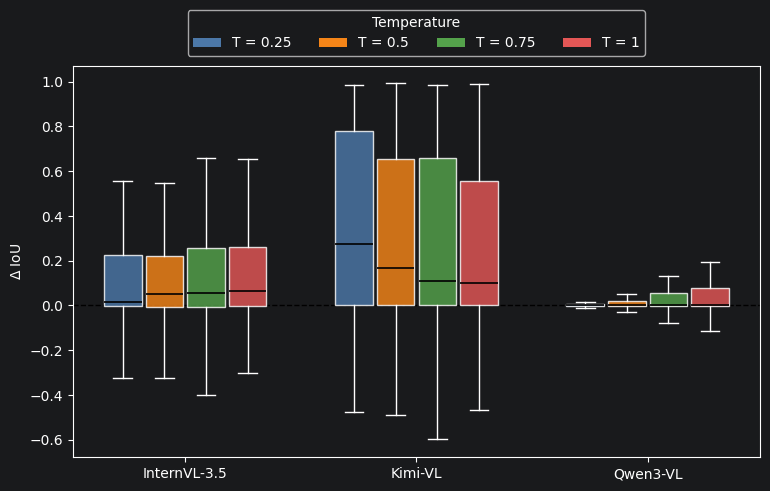

In [4]:
palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2"]
width = min(0.72 / len(temperatures), 0.18)
x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(max(7, 2.6 * len(models)), 5))
for index, temperature in enumerate(temperatures):
    offset = (index - (len(temperatures) - 1) / 2) * width
    values = [
        comparison.loc[
            (comparison["model"] == model) & (comparison["temperature"] == temperature),
            "temperature_iou_delta",
        ].dropna().to_numpy()
        for model in models
    ]
    boxes = ax.boxplot(
        values, positions=x + offset, widths=width * 0.9,
        patch_artist=True, showfliers=False, manage_ticks=False,
        medianprops={"color": "black", "linewidth": 1.2},
    )
    for box in boxes["boxes"]:
        box.set(facecolor=palette[index % len(palette)], alpha=0.82)

ax.axhline(0, color="black", lw=1, ls="--", zorder=0)
ax.set_xticks(x, [MODEL_LABEL.get(model, model) for model in models])
ax.set_ylabel(r"$\Delta$ IoU")
ax.legend(
    handles=[Patch(facecolor=palette[i % len(palette)], label=f"T = {temperature:g}")
             for i, temperature in enumerate(temperatures)],
    title="Temperature", ncol=len(temperatures), loc="upper center", bbox_to_anchor=(0.5, 1.16),
)
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "rq5_temperature_iou_delta_grouped_boxplot.pdf", dpi=200, bbox_inches="tight")
plt.show()


## Draft: testcase retention across temperature configurations

Each model–temperature position shows nested retention bars for ΔIoU tolerances of **0.001**, **0.01**, and **0.1**. A testcase is retained when its temperature-run adversarial IoU is no more than the stated tolerance higher than its saved base result. The narrow dark foreground bar is the strict 0.001 definition; wider, lighter background layers relax the tolerance.

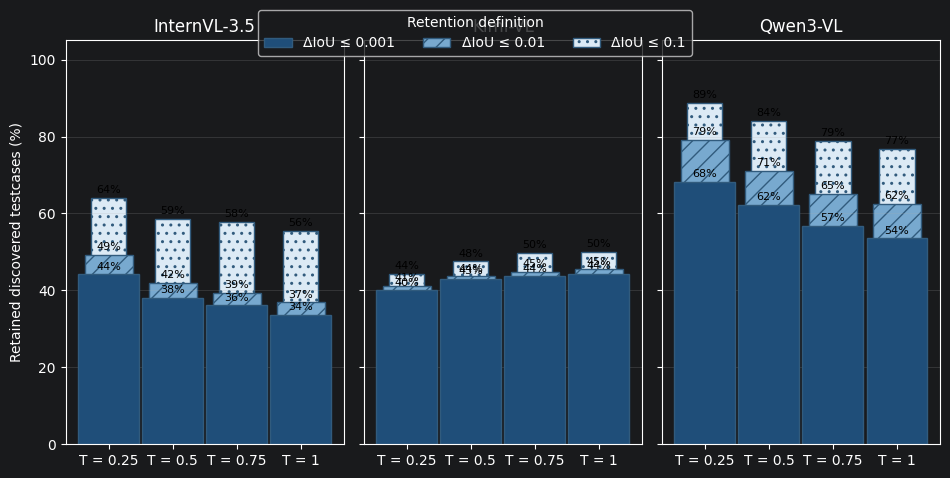

iou_tolerance,Model,Temperature,ΔIoU ≤ 0.001 (%),ΔIoU ≤ 0.01 (%),ΔIoU ≤ 0.1 (%)
0,InternVL-3.5,0.25,44.19,49.24,64.14
1,InternVL-3.5,0.50,38.13,41.92,58.59
2,InternVL-3.5,0.75,36.11,39.39,57.83
3,InternVL-3.5,1.00,33.59,36.87,55.56
4,Kimi-VL,0.25,40.00,41.21,44.24
5,Kimi-VL,0.50,43.03,43.64,47.58
6,Kimi-VL,0.75,43.64,44.85,49.70
7,Kimi-VL,1.00,44.24,45.45,50.00
8,Qwen3-VL,0.25,68.22,79.09,88.77
9,Qwen3-VL,0.50,62.25,71.09,83.99


In [6]:
IOU_TOLERANCES = [0.001, 0.01, 0.10]

retention = pd.concat(
    [
        comparison.assign(retained=lambda frame: frame["temperature_iou_delta"] <= tolerance)
        .groupby(["model", "temperature"], as_index=False)
        .agg(n=("retained", "size"), retained_fraction=("retained", "mean"))
        .assign(iou_tolerance=tolerance)
        for tolerance in IOU_TOLERANCES
    ],
    ignore_index=True,
)
retention["retained_percentage"] = 100 * retention["retained_fraction"]

# Draw the most permissive definition first as the widest background layer;
# stricter definitions remain visible as progressively narrower foreground bars.
threshold_styles = {
    0.001: {"facecolor": "#1F4E79", "hatch": "", "label": "ΔIoU ≤ 0.001"},
    0.01: {"facecolor": "#78A9CF", "hatch": "//", "label": "ΔIoU ≤ 0.01"},
    0.10: {"facecolor": "#DCEAF5", "hatch": "..", "label": "ΔIoU ≤ 0.1"},
}

fig, axes = plt.subplots(1, len(models), figsize=(max(9, 3.2 * len(models)), 4.8), sharey=True)
axes = np.atleast_1d(axes)
for ax, model in zip(axes, models):
    positions = np.arange(len(temperatures))
    for index, tolerance in list(enumerate(IOU_TOLERANCES)):
        subset = retention.loc[
            (retention["model"] == model) & (retention["iou_tolerance"] == tolerance)
        ].set_index("temperature")
        values = [subset.loc[temperature, "retained_percentage"] for temperature in temperatures]
        style = threshold_styles[tolerance]
        bars = ax.bar(
            positions, values,
            width=0.35 + 0.20 * (len(threshold_styles)-index),
            facecolor=style["facecolor"], edgecolor="#315B7D", linewidth=1,
            hatch=style["hatch"], zorder=2 - index,
        )
        ax.bar_label(bars, labels=[f"{value:.0f}%" for value in values], padding=2, fontsize=8, color="black")

    ax.set_title(MODEL_LABEL.get(model, model))
    ax.set_xticks(positions, [f"T = {temperature:g}" for temperature in temperatures])
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.25, zorder=0)

axes[0].set_ylabel("Retained discovered testcases (%)")
fig.legend(
    handles=[Patch(facecolor=threshold_styles[t]["facecolor"], edgecolor="#315B7D", hatch=threshold_styles[t]["hatch"], label=threshold_styles[t]["label"])
             for t in IOU_TOLERANCES],
    title="Retention definition", ncol=len(IOU_TOLERANCES), loc="upper center", bbox_to_anchor=(0.5, 1.0),
)
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "rq5_testcase_retention_tolerance_sweep_draft.pdf", dpi=200, bbox_inches="tight")
plt.show()

retention_table = retention.pivot(
    index=["model", "temperature"], columns="iou_tolerance", values="retained_percentage"
).reset_index()
retention_table["model"] = retention_table["model"].map(MODEL_LABEL).fillna(retention_table["model"])
retention_table = retention_table.rename(columns={
    "model": "Model", "temperature": "Temperature",
    **{tolerance: f"ΔIoU ≤ {tolerance:g} (%)" for tolerance in IOU_TOLERANCES},
})
display(retention_table.round(2))